# **Decision Tree Analysis for Heart Disease Predictions**

1. Introduction to decision trees

---



***-> What's a Decision Tree?***


>A Decision Tree is a machine learning algorithm which uses labelled input and output datasets to train models. The approach is used mainly to solve classification and regression problems.
It is called a "tree" because of its hierarchical structure.
Tree consists of internal nodes representing tests on features (attributes), branches that represent the outcomes of these tests, and leaf nodes that represent class labels or regression values.
The topmost node is called the root node, and it serves as the starting point for decision-making. The tree splits data into subsets based on the values of input features until the final decision.



***-> How does it work?***


>A decision tree works by learning simple decision rules from labeled input data to predict an outcome. It begins at the root node, which represents the initial question or condition related to a particular feature. Based on the answer to this question (true or false), the data is split into different branches, each leading to an internal node. These nodes continue asking further questions, refining the data with each step. This process of splitting continues until a stopping condition is met, such as a maximum tree depth, a minimum number of samples in a node, or all samples in a node belonging to the same class. At every level, the tree evaluates the feature that best separates the data to increase prediction accuracy. The result is a model that can be easily interpreted and visualized, making Decision Trees particularly useful in domains where explainability is important.


2. Data Preparation & Splitting

---



In [ ]:
#Importing all the necessary libraries.

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

from sklearn import tree
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
#Importing the Heart Disease dataset from a URL and loading it into a dataframe

url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
dataframe = pd.read_csv(url, encoding='utf-8')  #heart disease dataset with 14 features
dataframe

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


Understand dataset structure and content

In [ ]:
#Displaying basic information about the dataset: number of rows and columns,
# feature names, and the data types of each column

print("Informations of Database:")
print("• Number of rows : ", dataframe.shape[0])    #rows=dataframe.shape[0]
print("• Number of columns : ", dataframe.shape[1])  #columns=dataframe.shape[1]
print("• Names and Types of features : \n", dataframe.dtypes)

Informations of Database:
• Number of rows :  303
• Number of columns :  14
• Names and Types of features : 
 age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [ ]:
print(dataframe.describe())   #generate a statistical summary of the dataset

              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.366337    0.683168    0.966997  131.623762  246.264026    0.148515   
std      9.082101    0.466011    1.032052   17.538143   51.830751    0.356198   
min     29.000000    0.000000    0.000000   94.000000  126.000000    0.000000   
25%     47.500000    0.000000    0.000000  120.000000  211.000000    0.000000   
50%     55.000000    1.000000    1.000000  130.000000  240.000000    0.000000   
75%     61.000000    1.000000    2.000000  140.000000  274.500000    0.000000   
max     77.000000    1.000000    3.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.528053  149.646865    0.326733    1.039604    1.399340    0.729373   
std      0.525860   22.9051

Check for missing/null values in the dataset

In [ ]:
#check for null values in each column

dataframe.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
#check if any null values exist in the whole dataset

dataframe.isnull().sum().sum()

np.int64(0)

Plotting histograms of the dataset features to observe the distribution of values.




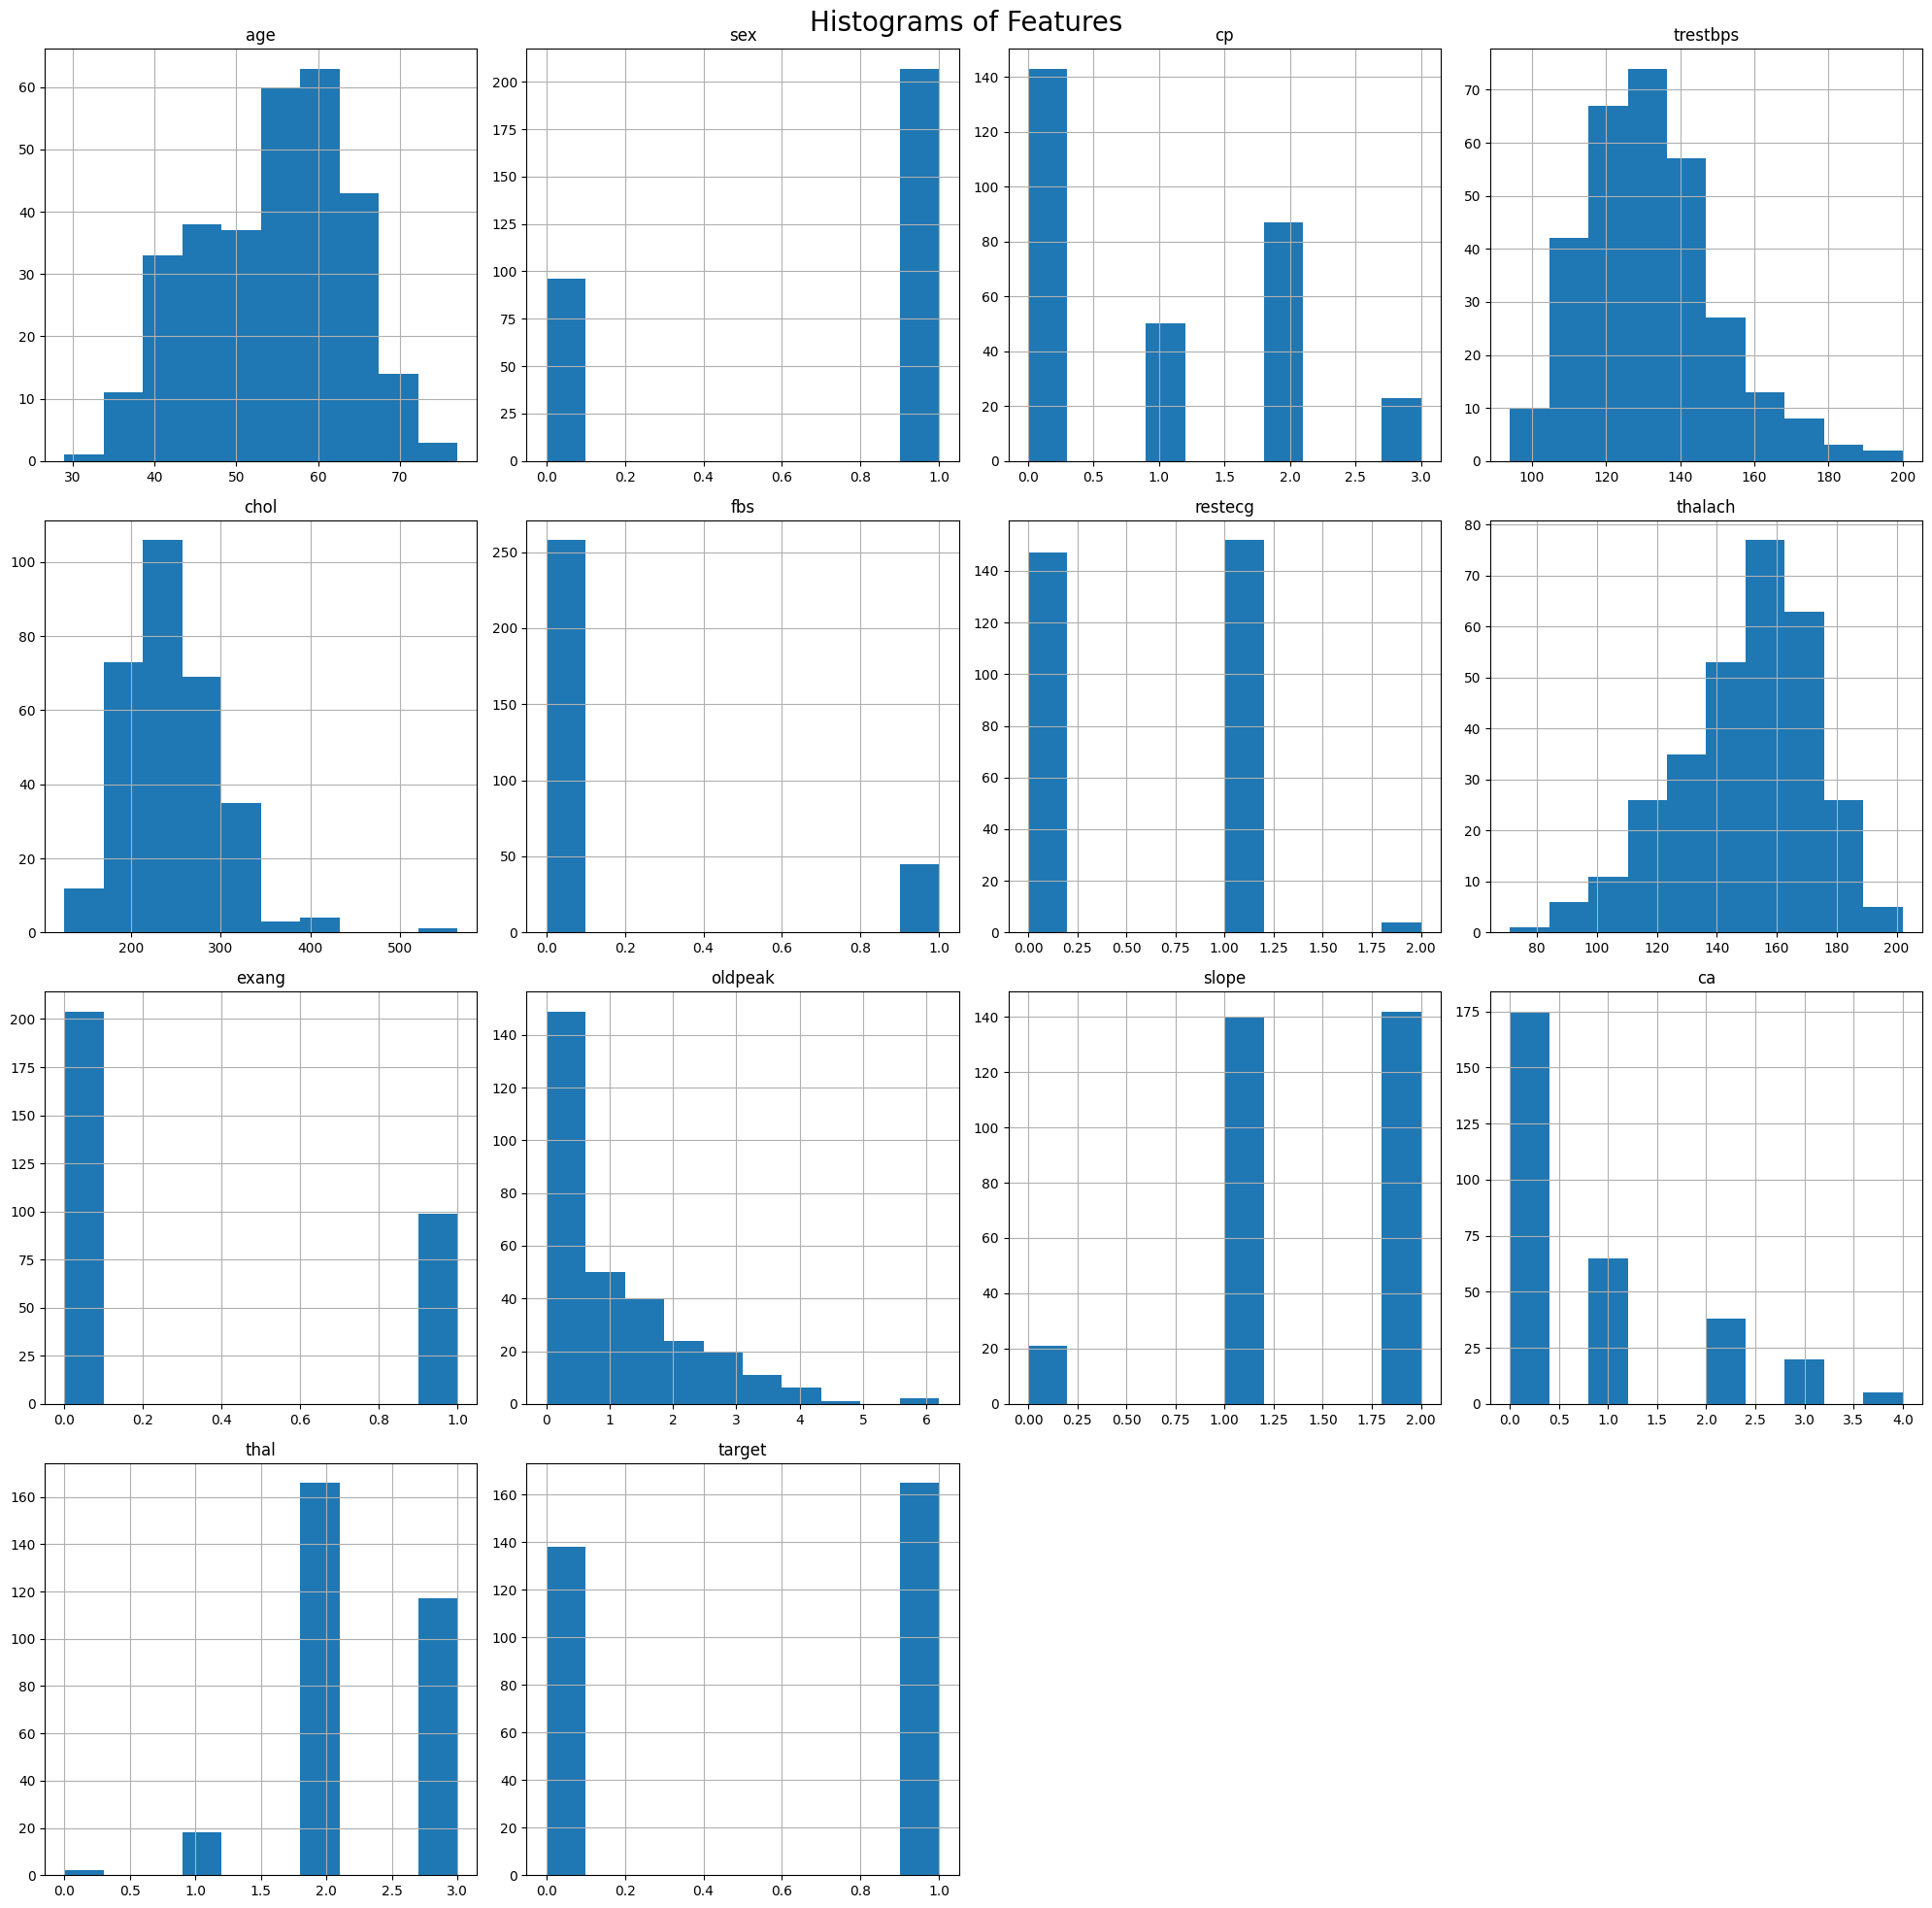

In [326]:
# Plotting histograms to visualize how the values are distributed across each numeric feature
# in the dataset before performing further analysis

dataframe.hist(figsize=(20,20))
plt.suptitle('Histograms of Features', fontsize=20)
plt.tight_layout()
plt.show()

The heatmap below visualizes how features are correlated with each other. Highly correlated variables may carry redundant information and can influence model performance.


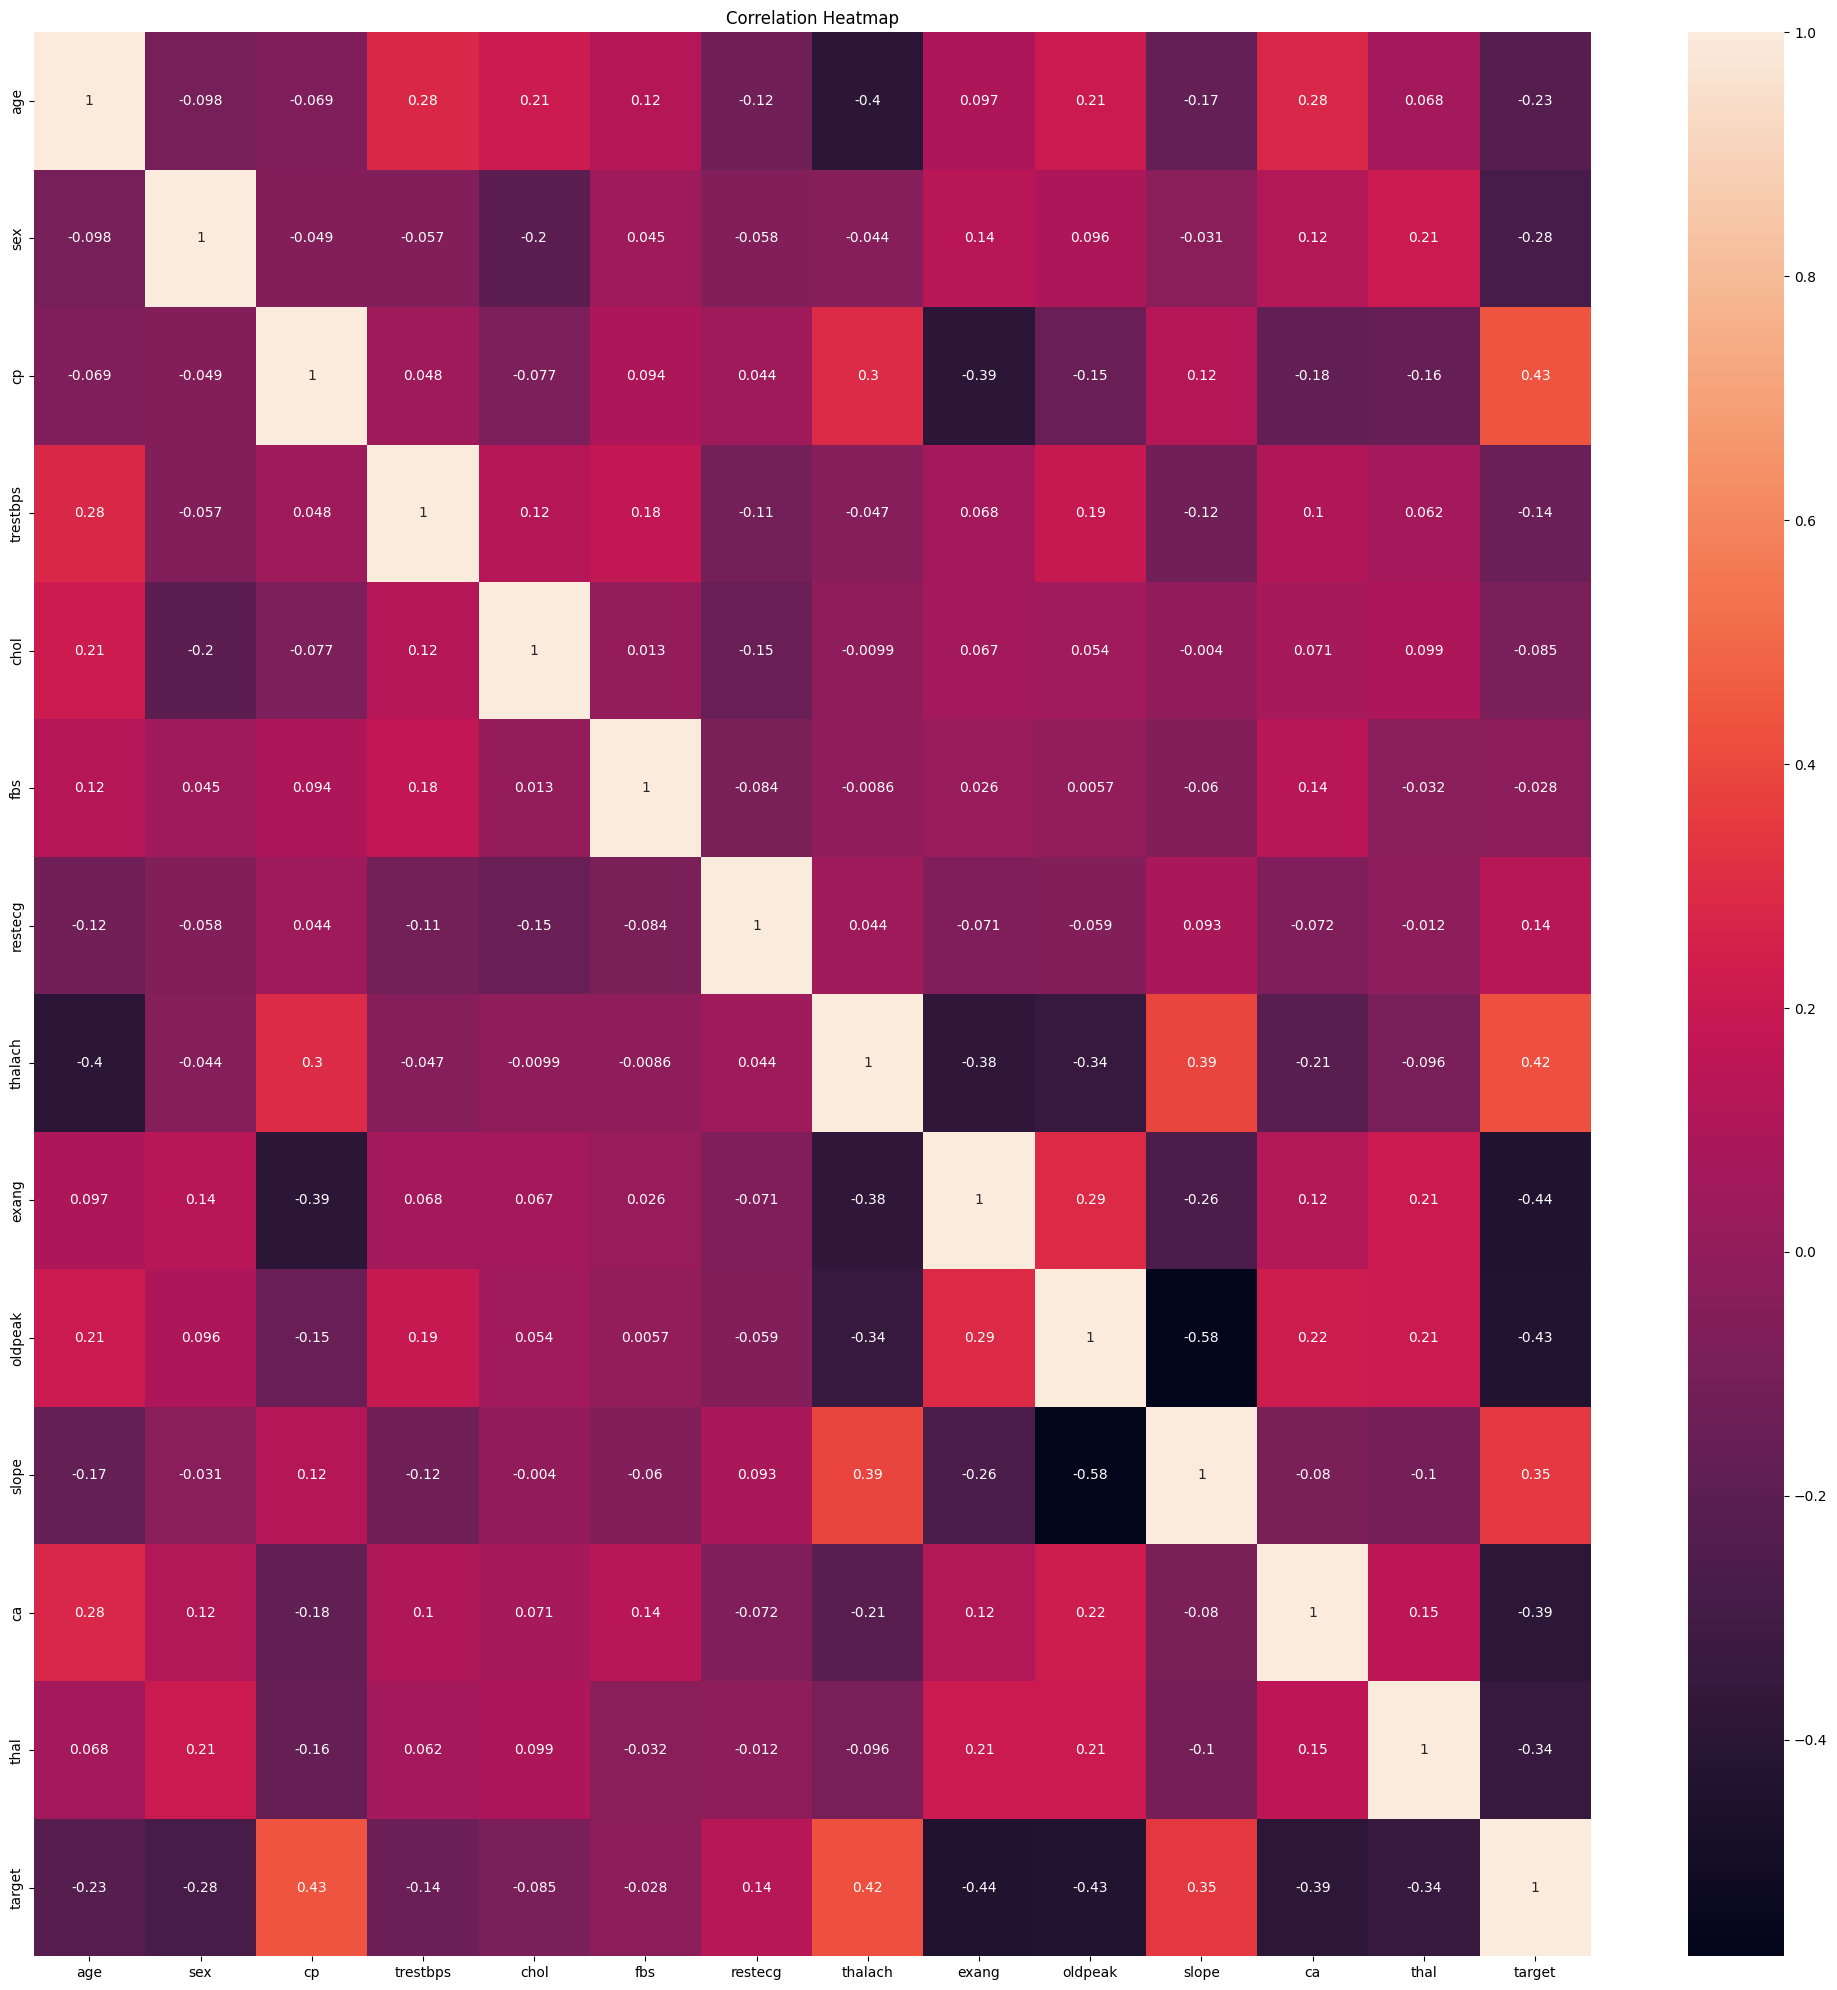

In [323]:
# Plotting a correlation heatmap to visualize the relationships
#between numeric features in the dataset

fig = plt.figure(figsize=(20,20))
plt.title("Correlation Heatmap")
_=sns.heatmap(dataframe.corr(),  annot=True)
plt.tight_layout()
plt.show()

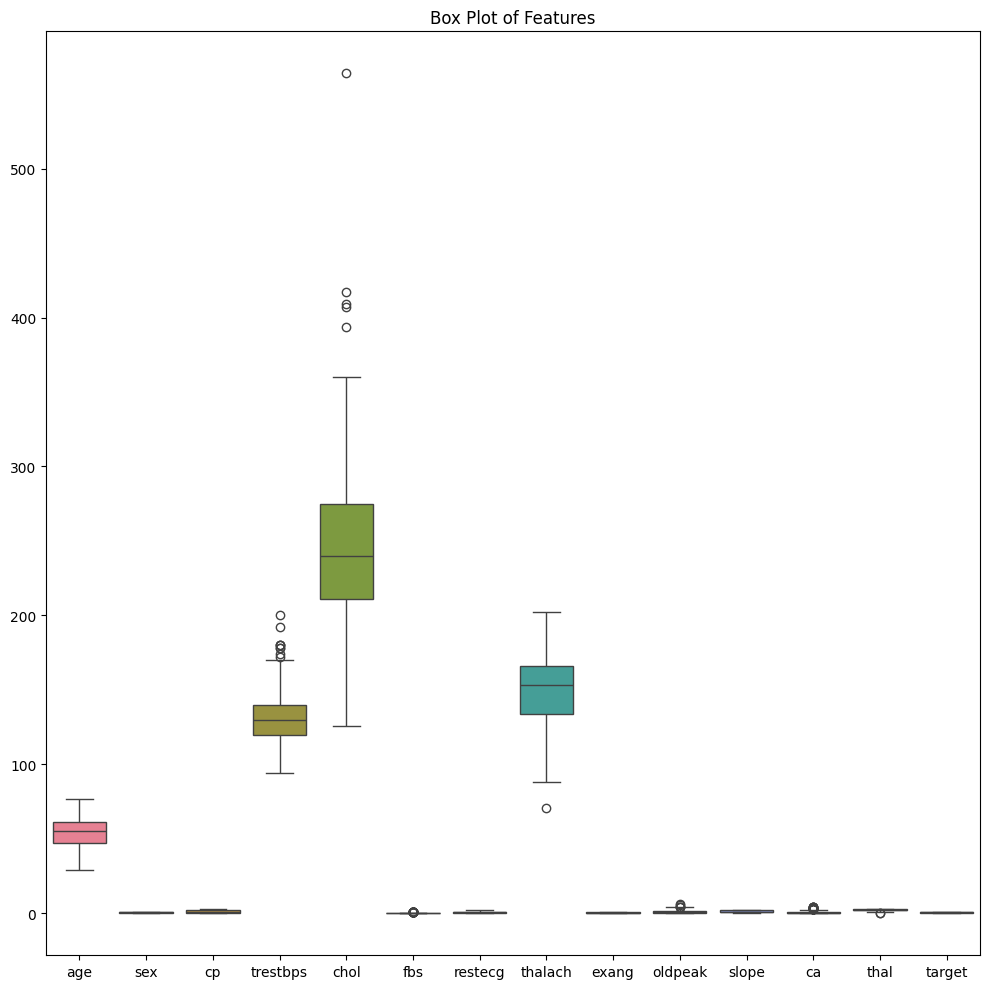

In [245]:
# Plotting boxplot to visualize the distribution, spread,
#skewness, and outliers in dataframe.

fig=plt.figure(figsize=(10,10))
_=sns.boxplot(dataframe)
plt.title('Box Plot of Features')
plt.tight_layout()
plt.show()

**Train-test split** is a technique used to divide a dataset into two parts: a training set and a testing set. The training set is used to teach the model, allowing it to learn patterns from the data. The testing set, on the other hand, is kept separate and is used to evaluate the model's performance on unseen data. This helps in assessing how well the model generalizes to new inputs and prevents overfitting.

In [299]:
#Train the model

# Define features (X) and target (y)
X = dataframe.drop(['target'], axis=1)
y=dataframe['target']

# Split the data into training and testing sets (67% train, 33% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

Parameters of train_test_split() function:

* X: features (input variables)

* y: target (label to predict)

* test_size=0.33: defines the proportion of the dataset to include in the test split. 0.33 means 33% of the data will be used for testing, and the rest (67%) for training

* random_state=42: controls the random number generator used when splitting the data. It ensures that the train-test split gets the same split every time you run the code.


3. Model Training & Visualization


---



In [320]:
# Try depth 4
clf_4 = DecisionTreeClassifier(max_depth=4, random_state=42)
clf_4.fit(X_train, y_train)
pred_4 = clf_4.predict(X_test)

# Try depth 5
clf_5 = DecisionTreeClassifier(max_depth=5, random_state=42)
clf_5.fit(X_train, y_train)
pred_5 = clf_5.predict(X_test)

print("Accuracy max_depth=4 :", accuracy_score(y_test, pred_4))
print("Accuracy max_depth=5 :", accuracy_score(y_test, pred_5))

Accuracy max_depth=4 : 0.74
Accuracy max_depth=5 : 0.76


There’s only a 2% increase in accuracy when increasing the depth, so setting the max depth to 4 is a better choice for healthcare. It keeps the model easier to understand and visualize. Even if a deeper tree slightly improves accuracy, it’s not worth the extra complexity, especially when explainability is important (clear decisions matter most).

In [321]:
#Initialize and train a Decision Tree model on the dataset

clf = DecisionTreeClassifier(max_depth=4, ccp_alpha=0.01) #initialize
clf.fit(X_train, y_train) #train

DecisionTreeClassifier(ccp_alpha=0.01, max_depth=4)

In [322]:
clf.get_depth()

4

In [250]:
#view hyperparameters

clf.get_params()

{'ccp_alpha': 0.01,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 4,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

**Explain hyperparameters:**

`'ccp_alpha': 0.01`

Complexity parameter used for Minimal Cost-Complexity Pruning. The subtree with the largest cost complexity that is smaller than ccp_alpha will be chosen. 0.01 means small subtrees that don’t improve performance much will be removed to ovoid overfitting.

` 'class_weight': None`

Weights associated with classes in the form {class_label: weight}. If None, all classes are supposed to have weight one.


` 'criterion': 'gini'`

The function to measure the quality of a split. Supported criteria are “gini” for the Gini impurity.

` 'max_depth': 4`

The maximum depth of the tree is equal to 4.

` 'max_features': None`

The number of features to consider when looking for the best split.If None, then max_features=n_features.

` 'max_leaf_nodes': None`

Best nodes are defined as relative reduction in impurity. If None then unlimited number of leaf nodes.

` 'min_impurity_decrease': 0.0`

A node will be split if this split induces a decrease of the impurity greater than or equal to this value.

` 'min_samples_leaf': 1`

The minimum number of samples required to be at a leaf node.

` 'min_samples_split': 2`

he minimum number of samples required to split an internal node.

` 'min_weight_fraction_leaf': 0.0`

The minimum weighted fraction of the sum total of weights (of all the input samples) required to be at a leaf node. Samples have equal weight when sample_weight is not provided.

` 'monotonic_cst': None`

Indicates the monotonicity constraint to enforce on each feature.If monotonic_cst is None, no constraints are applied.

` 'random_state': None`

Controls the randomness of the estimator.

` 'splitter': 'best'`

The strategy used to choose the split at each node. Supported strategies are “best” to choose the best split and “random” to choose the best random split.




In [ ]:
clf.classes_

array([0, 1])

The plot below represents the trained decision tree. Each node shows the feature used for splitting, the Gini index, and the class prediction.

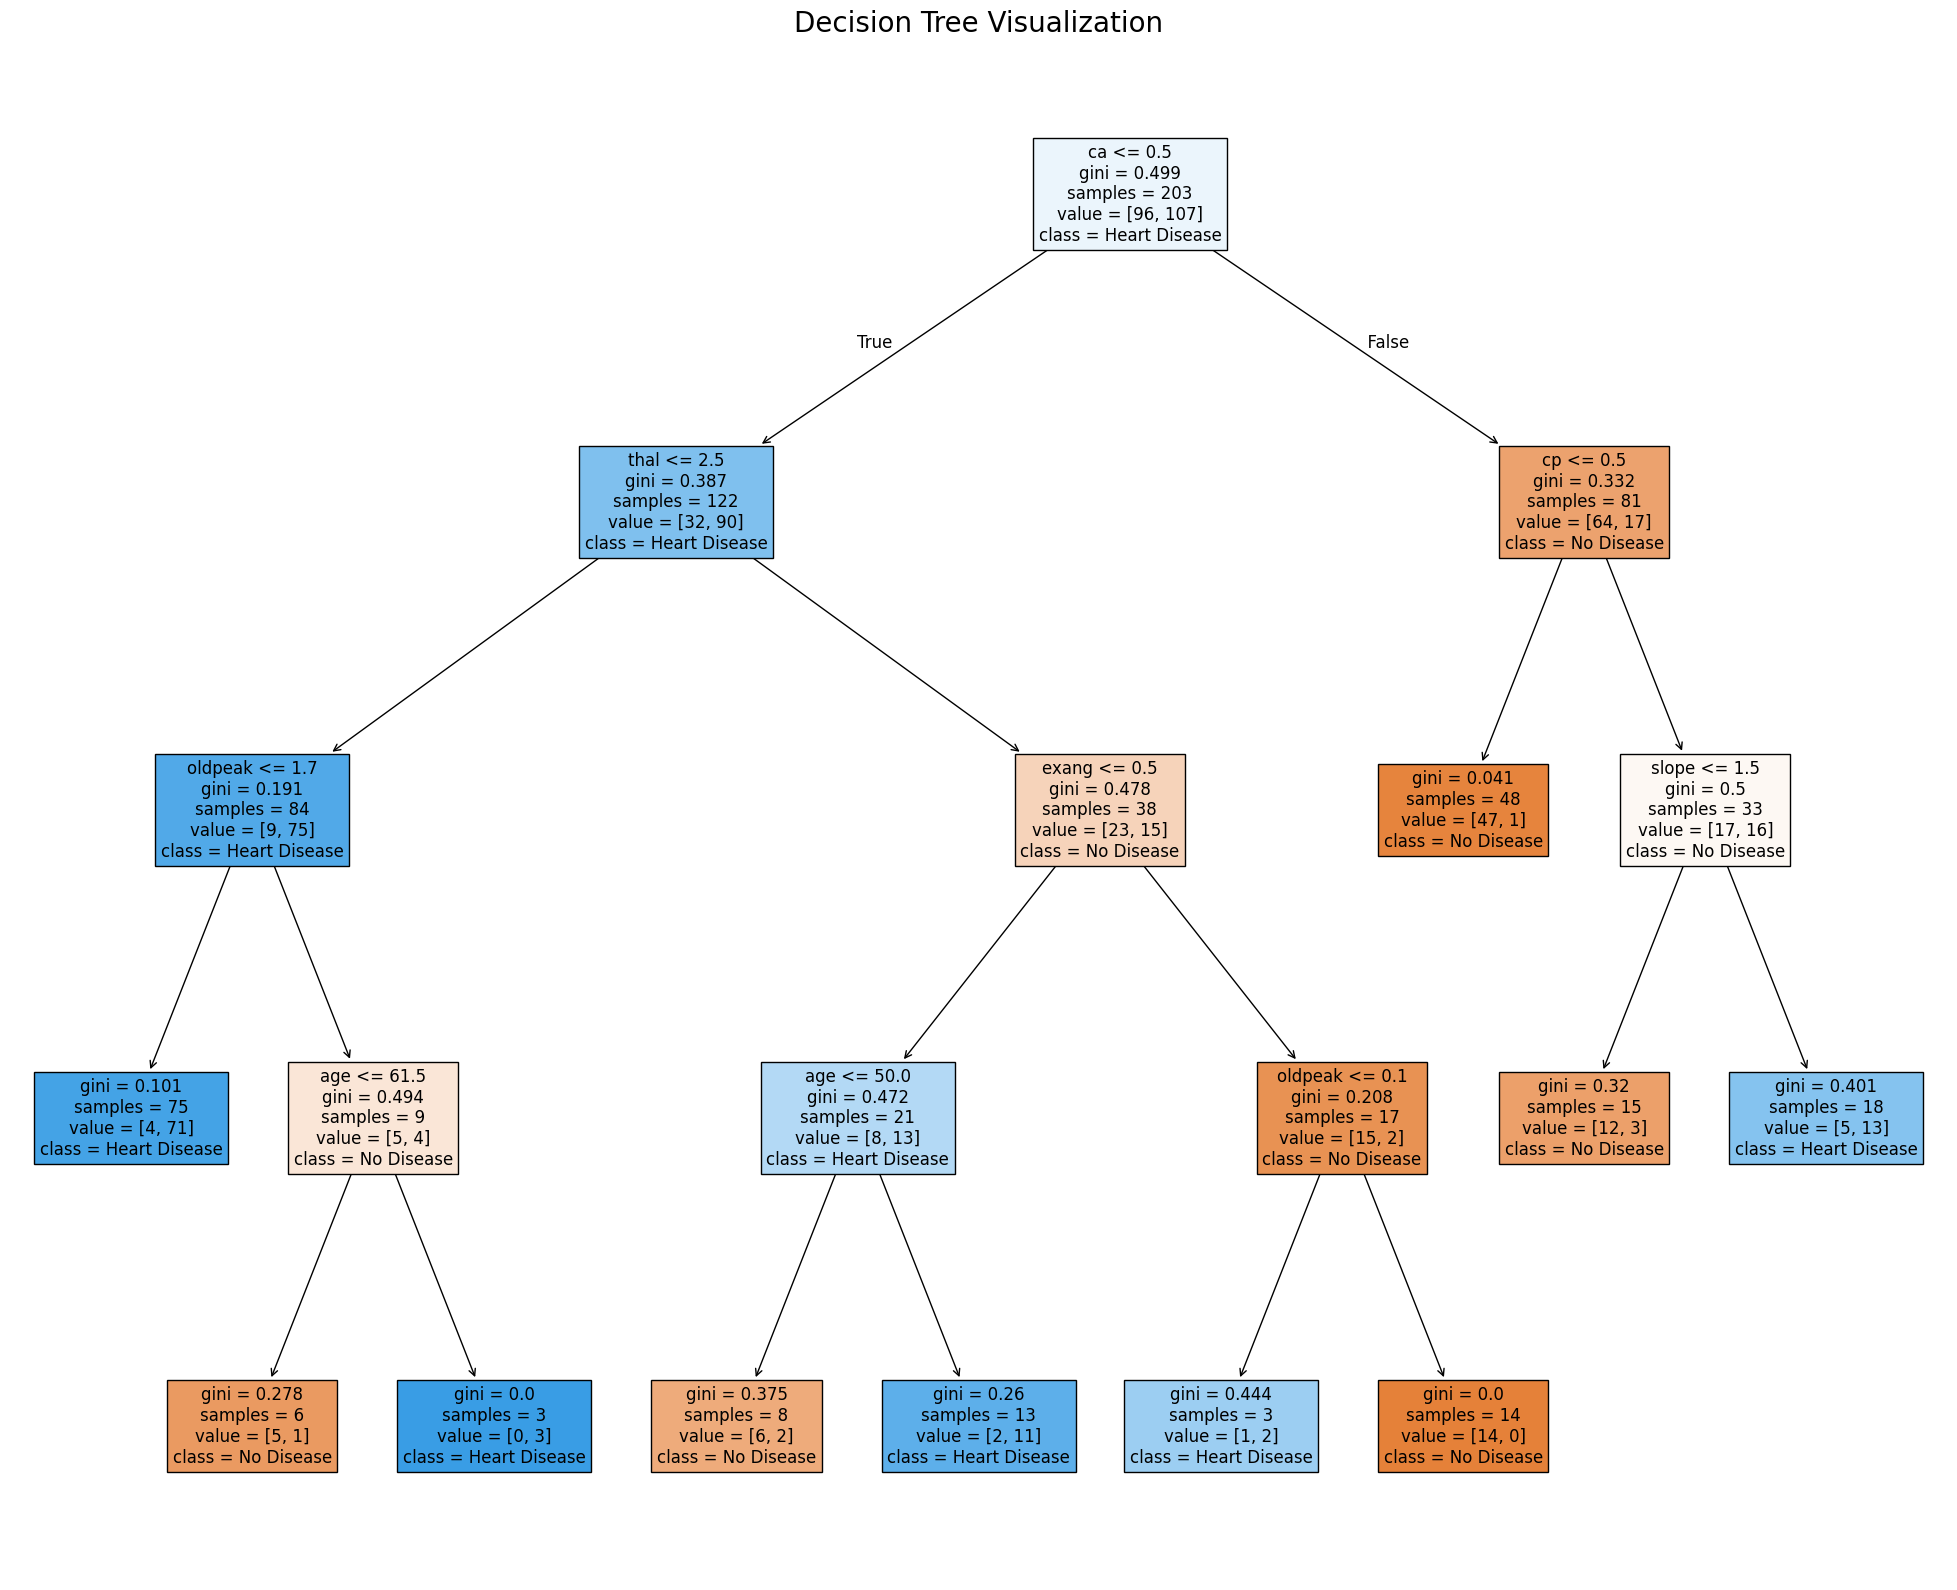

In [327]:
# Visualizing the trained decision tree

fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(
    clf,
    feature_names=X.columns,
    class_names=['No Disease', 'Heart Disease'],
    filled=True,
    fontsize=12
)
plt.title("Decision Tree Visualization", fontsize=20)
plt.show()

* Each internal node: test one attribute X or the value of feature against a threshold
* Each branch from a node: selects one value for X
* Each leaf node: predict Y (p(Y|x ∈ leaf)

The decision tree graph shows how the model splits data based on different features to classify tumors as Malignant or Benign (0 => No Desease, 1 => Heart Desease). Each node represents a decision based on a feature threshold, and the tree branches until it reaches a final prediction. The color (orange for No Desease, blue for Heart Desease) and label of each node show the predicted class and how confident the model is at that point.
The deeper the color, the more confident the prediction.
The top of the tree (where the model starts splitting) holds the most important decisions, and as you move down, the decisions become more specific.

4. Model Evaluation

---



In [252]:
#Predict on test data

predictions = clf.predict(X_test)
predictions

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0])

In [253]:
clf.predict_proba(X_test) #probabilities for each class

array([[0.97916667, 0.02083333],
       [0.15384615, 0.84615385],
       [0.27777778, 0.72222222],
       [0.97916667, 0.02083333],
       [0.27777778, 0.72222222],
       [0.05333333, 0.94666667],
       [0.05333333, 0.94666667],
       [0.97916667, 0.02083333],
       [0.97916667, 0.02083333],
       [0.8       , 0.2       ],
       [0.05333333, 0.94666667],
       [0.15384615, 0.84615385],
       [0.05333333, 0.94666667],
       [1.        , 0.        ],
       [0.05333333, 0.94666667],
       [0.05333333, 0.94666667],
       [0.05333333, 0.94666667],
       [0.97916667, 0.02083333],
       [0.97916667, 0.02083333],
       [0.97916667, 0.02083333],
       [0.15384615, 0.84615385],
       [1.        , 0.        ],
       [0.05333333, 0.94666667],
       [0.27777778, 0.72222222],
       [0.8       , 0.2       ],
       [0.75      , 0.25      ],
       [0.05333333, 0.94666667],
       [0.05333333, 0.94666667],
       [0.97916667, 0.02083333],
       [0.05333333, 0.94666667],
       [0.

In [316]:
#calculate accuracy

#The accuracy score gives us the percentage of correct predictions.

print("Accuracy:", accuracy_score(y_test, predictions))

Accuracy: 0.79


In [255]:
#calculate precision

#The precision score gives us the percentage of positive predictions
#that were actually correct.
#Precision is about the quality of the positive predictions.

print("Precision:",precision_score(y_test, predictions))

Precision: 0.8627450980392157


In [256]:
#calculate recall

#The recall score gives us the percentage of actual positive
#instances that were correctly predicted by the model.
#Recall is about how many of the true positives were captured.

print("Recall:",recall_score(y_test, predictions))

Recall: 0.7586206896551724


In [257]:
#evaluate the classifier’s performance

report = classification_report(y_test, predictions, target_names=['No Disease', 'Heart Disease'])
print(report)

               precision    recall  f1-score   support

   No Disease       0.71      0.83      0.77        42
Heart Disease       0.86      0.76      0.81        58

     accuracy                           0.79       100
    macro avg       0.79      0.80      0.79       100
 weighted avg       0.80      0.79      0.79       100



In [258]:
#Confusion Matrix

cm = confusion_matrix(y_test, predictions, labels=[0,1])
cm

array([[35,  7],
       [14, 44]])

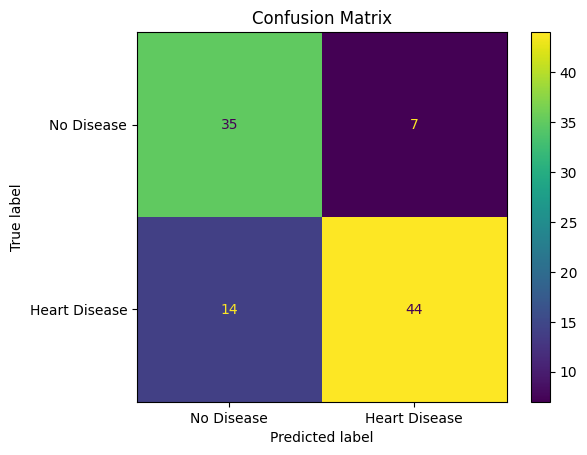

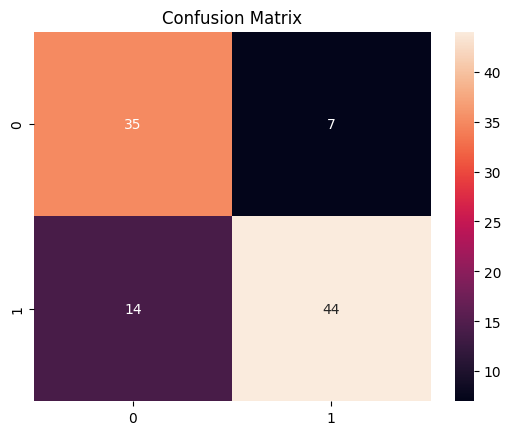

In [259]:
#Display the Confusion Matrix
dispCm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Heart Disease'])
dispCm.plot()
plt.title("Confusion Matrix")
plt.show()

#another way to visualize the confusion matrix by using heatmap
sns.heatmap(cm, annot=True)
plt.title("Confusion Matrix")
plt.show()

-->   In the confusion matrix, the top left cell (35) shows the number of 'no desease' cases that were correctly predicted as 'no desese' (true positives).


-->The top right cell (7) shows the number of 'no desease' cases that were incorrectly predicted as 'heart desease' (false negatives).


-->The bottom left cell (14) shows the number of 'heart desease' cases that were incorrectly predicted as 'no desease' (false positives).


-->The bottom right cell (44) shows the number of 'heart desease' cases that were correctly predicted as 'heart desease' (true negatives).


5. Final Analysis & Conclusion


---



In [260]:
print(clf.feature_importances_)

[0.08963299 0.         0.11984914 0.         0.         0.
 0.         0.         0.06722869 0.08894707 0.06351275 0.38604213
 0.18478723]


In [261]:
feature_names=X.columns
feature_importance = pd.DataFrame(clf.feature_importances_, index = feature_names).sort_values(0, ascending=False)
feature_importance

,0
ca,0.386042
thal,0.184787
cp,0.119849
age,0.089633
oldpeak,0.088947
exang,0.067229
slope,0.063513
sex,0.000000
trestbps,0.000000
chol,0.000000


In [263]:
features = list(feature_importance[feature_importance[0]>0].index)
print('The most import features are:\n', features)

The most import features are:
 ['ca', 'thal', 'cp', 'age', 'oldpeak', 'exang', 'slope']


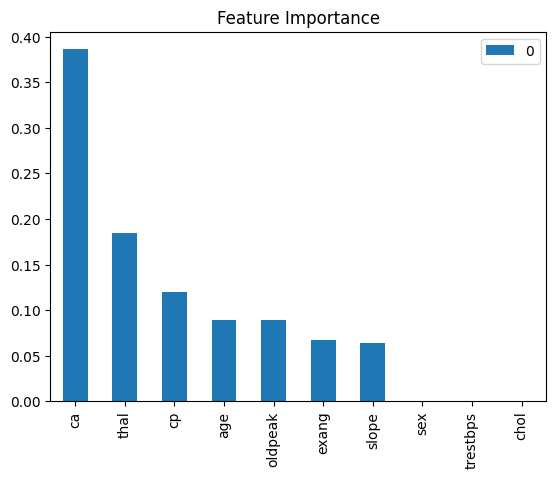

In [264]:
feature_importance.head(10).plot(kind='bar')
plt.title("Feature Importance")
plt.show()

The original dataset contains 14 columns, including the target variable, meaning a total of 13 features were initially considered for model training. However, based on analysis, only 7 features appear to be relevant for visualization and potentially for building a better-performing model. Therefore, removing the remaining features could help reduce noise and improve model efficiency.

In [314]:
low_importance = list(feature_importance[feature_importance[0]<0.07].index)

# Drop low importance features from the first dataframe X
X_reduced = X.drop(columns=low_importance)

X_reduced

,age,cp,oldpeak,ca,thal
0,63,3,2.3,0,1
1,37,2,3.5,0,2
2,41,1,1.4,0,2
3,56,1,0.8,0,2
4,57,0,0.6,0,2
...,...,...,...,...,...
298,57,0,0.2,0,3
299,45,3,1.2,0,3
300,68,0,3.4,2,3
301,57,0,1.2,1,3


In [301]:
#Displaying the new dataframe imformations
#without the unnecessary features

print("The database has:")
print("• Number of rows : ", X_reduced.shape[0])
print("• Number of columns : ", X_reduced.shape[1])
print("• Names and Types of features : \n", X_reduced.dtypes)

The database has:
• Number of rows :  303
• Number of columns :  5
• Names and Types of features : 
 age          int64
cp           int64
oldpeak    float64
ca           int64
thal         int64
dtype: object


In [302]:
print(X_reduced.describe())

              age          cp     oldpeak          ca        thal
count  303.000000  303.000000  303.000000  303.000000  303.000000
mean    54.366337    0.966997    1.039604    0.729373    2.313531
std      9.082101    1.032052    1.161075    1.022606    0.612277
min     29.000000    0.000000    0.000000    0.000000    0.000000
25%     47.500000    0.000000    0.000000    0.000000    2.000000
50%     55.000000    1.000000    0.800000    0.000000    2.000000
75%     61.000000    2.000000    1.600000    1.000000    3.000000
max     77.000000    3.000000    6.200000    4.000000    3.000000


In [303]:
#train new model

X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(X_reduced, y, test_size=0.33, random_state=42)

In [304]:
#Train new Decision Tree model

clf_new = DecisionTreeClassifier(max_depth=4, ccp_alpha=0.01)
clf_new.fit(X_train_new, y_train_new)

DecisionTreeClassifier(ccp_alpha=0.01, max_depth=4)

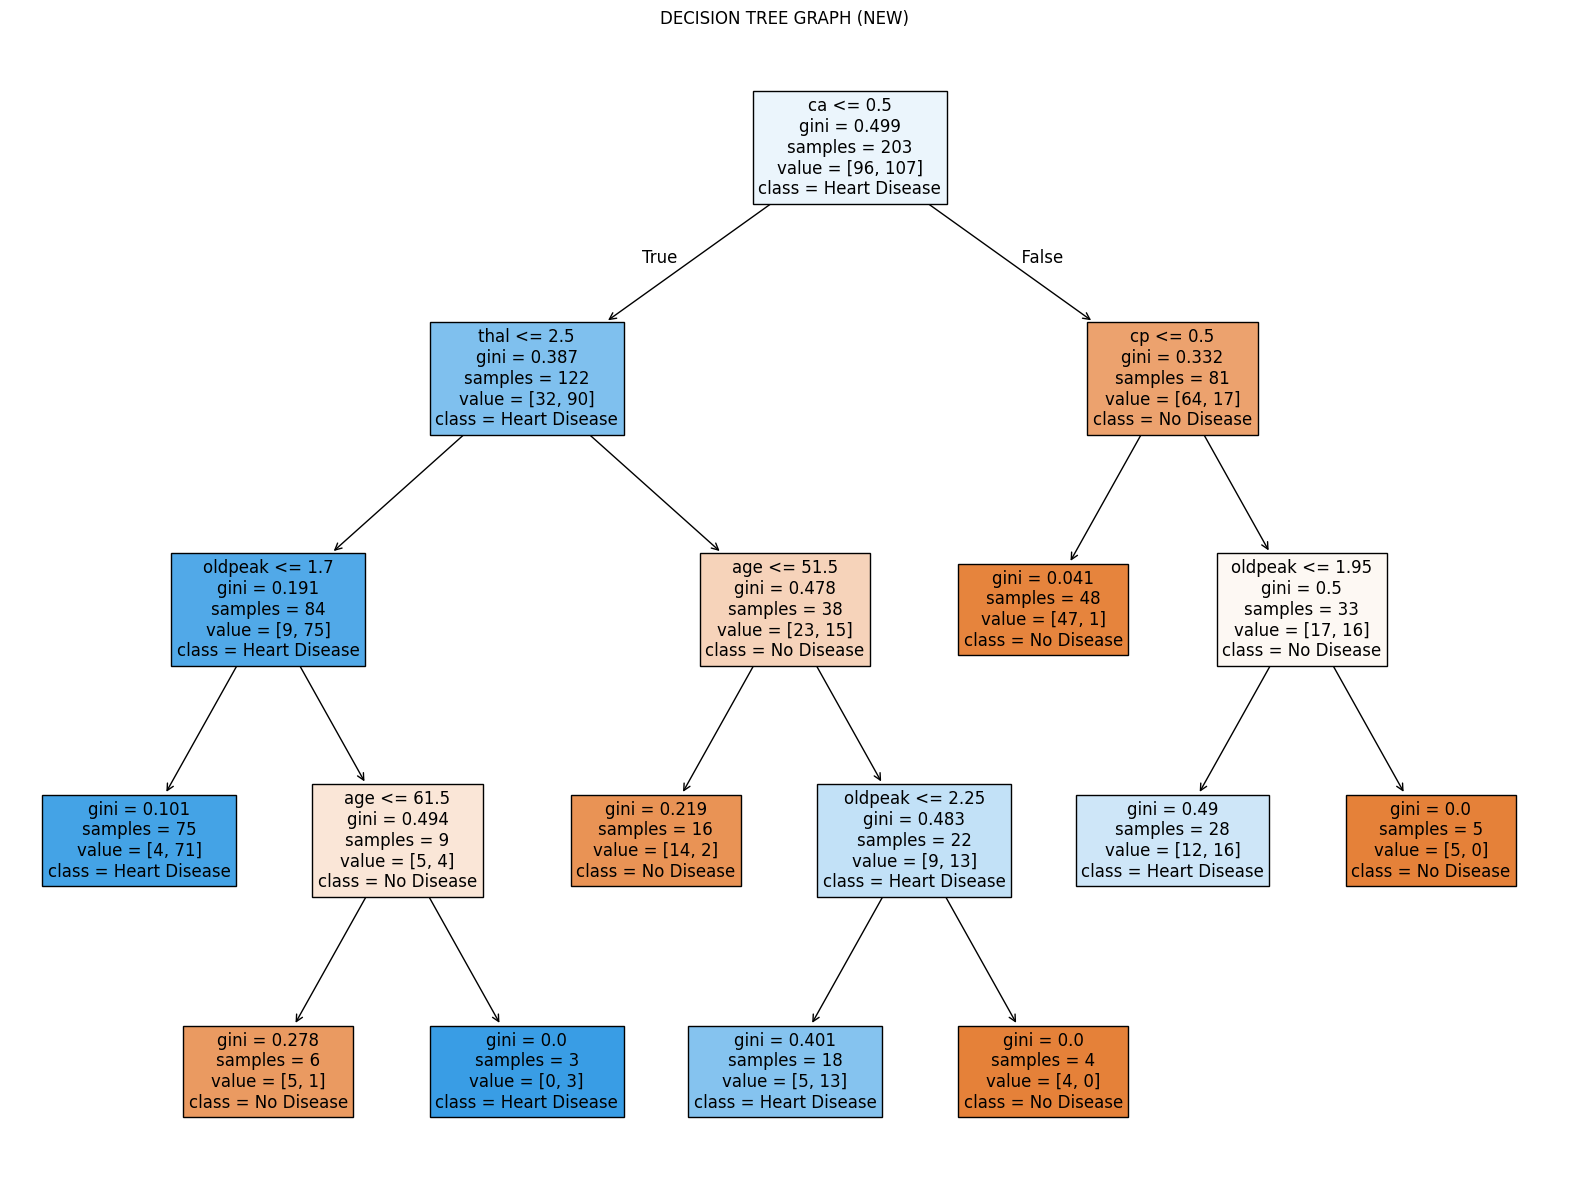

In [319]:
#display the decision tree graph

fig = plt.figure(figsize=(20,15))
_ = tree.plot_tree(
    clf_new,
    feature_names=X_reduced.columns,
    class_names=['No Disease', 'Heart Disease'],
    filled=True,
    fontsize=12
)
plt.title("DECISION TREE GRAPH (NEW)")
plt.show()

In [306]:
predictions_new = clf_new.predict(X_test_new)
predictions_new

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1,
       1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0,
       0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1])

In [307]:
#calculate accuracy

print("Accuracy:", accuracy_score(y_test_new, predictions_new))

Accuracy: 0.79


In [308]:
print("Precision:",precision_score(y_test_new, predictions_new))

Precision: 0.8245614035087719


In [309]:
print("Recall:",recall_score(y_test_new, predictions_new))

Recall: 0.8103448275862069


In [310]:
#evaluate the classifier’s performance

report_new = classification_report(y_test_new, predictions_new, target_names=['No Disease', 'Heart Disease'])
print(report_new)

               precision    recall  f1-score   support

   No Disease       0.74      0.76      0.75        42
Heart Disease       0.82      0.81      0.82        58

     accuracy                           0.79       100
    macro avg       0.78      0.79      0.79       100
 weighted avg       0.79      0.79      0.79       100



In [317]:
cm_new = confusion_matrix(y_test_new, predictions_new, labels=[0,1])
cm_new

array([[32, 10],
       [11, 47]])

In [312]:
print(clf_new.feature_importances_)

[0.10369996 0.1284335  0.15615073 0.41369294 0.19802288]


# **Final thoughts on the model's performance**


To predict the target variable, the model initially considered 13 features. However, after training the model and analyzing feature importance scores, it became evident that not all features contributed equally to the predictions.

Among the evaluated features, ca demonstrated the highest importance, followed closely by thal and cp. These variables significantly influenced the decision-making process of the model and were retained. On the other hand, features such as sex, trestbps, and chol showed zero importance scores, indicating they had no impact on the model’s outcomes.

To optimize performance, feature with importance under 0.07 were removed from the dataset. This decision was based on their lack of contribution to predictive accuracy and the potential drawbacks of including irrelevant variables, such as increased complexity and overfitting.

After removing features with low importance scores, the classification model retained its accuracy at 79%, demonstrating that excluding irrelevant variables did not hinder its predictive performance. While there were minor trade-offs between precision and recall for the two classes (No Disease and Heart Disease), the overall balance of metrics remained consistent. For the No Disease class, precision improved slightly, while recall dropped. Conversely, for the Heart Disease class, recall improved but precision decreased modestly.

These adjustments indicate that simplifying the feature set resulted in negligible impact on model performance, supporting the decision to streamline the dataset for better interpretability and reduced complexity. By focusing on the most influential features, the model is optimized to generalize effectively to new data and is better equipped for practical use. Overall, the revised feature set enhances both the efficiency and reliability of the predictive system.
